# Análisis Exploratorio de Datos (EDA): Avazu Click-Through Rate Prediction

**Autores:** Juan Camilo Mendoza Arango[✉](mailto:cjarango@uninorte.edu.co), Miguel Ángel Pérez Vargas[✉](mailto:vargasmiguel@uninorte.edu.co)

## Introducción

El presente proyecto aborda el problema de la predicción de clics en publicidad digital mediante técnicas de clasificación supervisada, utilizando el conjunto de datos “Avazu Click-Through Rate Prediction”. El objetivo es construir un modelo capaz de predecir si un usuario realizará clic en un anuncio móvil a partir de diferentes características asociadas con el anuncio, el sitio o aplicación donde se presenta, el dispositivo utilizado y el contexto de la impresión.

Dentro de la publicidad digital, el Click-Through Rate (CTR) constituye una métrica fundamental para evaluar la interacción de los usuarios con los anuncios. La capacidad de predecir esta respuesta permite identificar patrones asociados con una mayor probabilidad de clic y representa un problema especialmente interesante desde el aprendizaje automático debido al gran volumen de información generado y a la presencia de múltiples variables categóricas.

En este proyecto, la predicción será abordada mediante técnicas de Deep Learning, específicamente a través de una red neuronal multicapa (Multilayer Perceptron - MLP). Como primera etapa, se realizará un Análisis Exploratorio de Datos (EDA) orientado a comprender la estructura y calidad de la información disponible, identificar patrones relevantes y establecer las decisiones de preprocesamiento necesarias para la posterior construcción y evaluación del modelo.


:::{admonition} Nota Metodológica: Origen y Composición del Conjunto de Datos
:class: note

Para este proyecto se utiliza el conjunto de datos “Avazu Click-Through Rate Prediction”, correspondiente a una competencia de Kaggle orientada a la predicción de clics en anuncios móviles. El conjunto de entrenamiento contiene aproximadamente 40 millones de registros correspondientes a impresiones publicitarias recopiladas durante varios días consecutivos.

Cada observación representa una impresión de un anuncio y contiene información anonimizada asociada con diferentes elementos del proceso publicitario. Entre los principales atributos se encuentran:

* `id`: identificador de la impresión publicitaria.

* `hour`: información temporal de la impresión en formato YYMMDDHH.

* `C1` y `C14-C21`: variables categóricas anonimizadas.

* `banner_pos`: posición del anuncio.

* `site_id`, `site_domain`, `site_category`: información asociada con el sitio.

* `app_id`, `app_domain`, `app_category`: información asociada con la aplicación.

* `device_id`, `device_ip`, `device_model`: información anonimizada asociada con el dispositivo.

* `device_type`, `device_conn_type`: características relacionadas con el tipo de dispositivo y su conexión.

El objetivo de clasificación se encuentra definido por la variable `click`, una clase binaria donde el valor $1$ indica que se produjo un clic sobre el anuncio y el valor $0$ representa una impresión sin clic. Debido al tamaño del conjunto de datos y a la naturaleza predominantemente categórica de sus atributos, el análisis exploratorio permitirá estudiar aspectos como la distribución de la variable objetivo, la cardinalidad de las características, la información temporal disponible y la calidad general de los datos antes de iniciar el proceso de modelado.

:::

In [1]:
import sys
from pathlib import Path
import io
import os
import base64

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from IPython.display import display, HTML


def smart_format(x, fmt):
    """Safely format numeric values while preserving NaNs and strings."""
    if pd.isna(x) or isinstance(x, str):
        return x
    try:
        return fmt.format(x)
    except (ValueError, TypeError):
        return x


PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"
DATA_PATH = PROJECT_ROOT / "Data" / "train.csv"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from eda_toolkit import *

if "df" not in globals():
    df = pd.read_csv(DATA_PATH)

## Distribución de la Variable Click

Inicialmente, se analiza la distribución de la variable objetivo (`click`), la cual constituye el eje central del problema de clasificación planteado. Esta variable binaria indica si una impresión publicitaria generó una interacción por parte del usuario, tomando el valor 0 cuando no se produjo un clic y 1 cuando el usuario hizo clic sobre el anuncio. Examinar la proporción entre ambas clases permite conocer la frecuencia con la que ocurre el evento de interés e identificar posibles desbalances que puedan influir posteriormente en el proceso de modelado.

El siguiente gráfico ilustra la distribución de la variable `click` en el conjunto de datos:


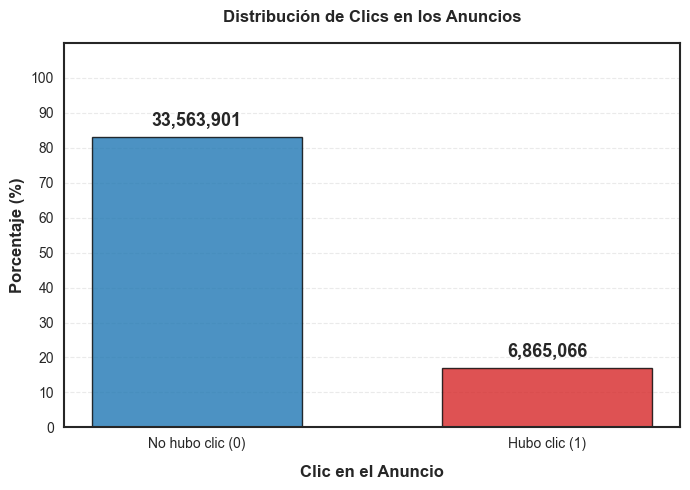

In [5]:
plot_categorical_distribution(
    df,
    column="click",
    display_name="Clic en el Anuncio",
    level_mapping={
        0: "No hubo clic (0)",
        1: "Hubo clic (1)"
    },
    title="Distribución de Clics en los Anuncios",
    ylabel="Porcentaje (%)"
)

Tal como se observa en la figura, la variable objetivo presenta un desbalance considerable entre sus dos clases. De las 40,428,967 impresiones publicitarias registradas, 33,563,901 (83.02%) no generaron un clic, mientras que 6,865,066 (16.98%) sí produjeron una interacción. Esto indica que los casos sin clic son aproximadamente cinco veces más frecuentes que aquellos en los que el usuario interactúa con el anuncio.

Esta distribución constituye un aspecto relevante para las etapas posteriores del proyecto, ya que un modelo podría obtener un desempeño aparentemente elevado si favorece sistemáticamente la clase mayoritaria. Por esta razón, durante el proceso de entrenamiento y evaluación será importante considerar el comportamiento del modelo frente a ambas clases y no limitar el análisis únicamente a métricas globales como la exactitud (`accuracy`). Este hallazgo deberá tenerse en cuenta posteriormente al definir la estrategia de modelado y las métricas utilizadas para evaluar el MLP.

## Verificación de Tipos de Datos y Valores Faltantes

Una vez analizada la distribución de la variable objetivo, se realiza una revisión general de la estructura del conjunto de datos con el propósito de identificar los tipos de datos asignados a cada atributo y evaluar la presencia de valores faltantes. Este diagnóstico permite verificar la integridad inicial de la información y reconocer variables que puedan requerir ajustes antes de las etapas posteriores de transformación y modelado.

Inicialmente, se presenta un resumen de los tipos de datos y la cantidad de valores disponibles y faltantes para cada variable:

In [6]:
data_quality = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str).values,
    "Valores no nulos": df.notna().sum().values,
    "Valores faltantes": df.isna().sum().values,
    "Faltantes (%)": (df.isna().mean().values * 100)
})

format_dict_quality = {
    "Valores no nulos": lambda x: smart_format(x, "{:,.0f}"),
    "Valores faltantes": lambda x: smart_format(x, "{:,.0f}"),
    "Faltantes (%)": lambda x: smart_format(x, "{:.2f}%")
}

styled_quality = data_quality.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_quality = styled_quality.set_properties(
    subset=["Variable"],
    **{"text-align": "left"}
)

styled_quality = styled_quality.set_properties(
    subset=[
        "Tipo de dato",
        "Valores no nulos",
        "Valores faltantes",
        "Faltantes (%)"
    ],
    **{"text-align": "center"}
)

styled_quality = styled_quality.format(format_dict_quality)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_quality.to_html()
        + "</div>"
    )
)

Variable,Tipo de dato,Valores no nulos,Valores faltantes,Faltantes (%)
id,float64,"40,428,967",0,0.00%
click,int64,"40,428,967",0,0.00%
hour,int64,"40,428,967",0,0.00%
C1,int64,"40,428,967",0,0.00%
banner_pos,int64,"40,428,967",0,0.00%
site_id,object,"40,428,967",0,0.00%
site_domain,object,"40,428,967",0,0.00%
site_category,object,"40,428,967",0,0.00%
app_id,object,"40,428,967",0,0.00%
app_domain,object,"40,428,967",0,0.00%


El diagnóstico inicial evidencia que las 24 variables del conjunto de datos cuentan con información completa para las 40,428,967 observaciones, **sin registrarse valores faltantes (`NaN`) en ninguno de los atributos**. Por lo tanto, **no** se requiere implementar **estrategias de imputación** asociadas con valores ausentes en esta etapa del análisis.

En cuanto a los tipos de datos, se observa una combinación de variables almacenadas como `object` e `int64`. Los atributos relacionados con identificadores de sitios, aplicaciones y dispositivos se encuentran representados principalmente como objetos, mientras que otras características, incluidas varias de las variables anonimizadas, fueron interpretadas como valores enteros. Sin embargo, esta representación numérica no implica necesariamente una naturaleza cuantitativa, ya que varias de estas variables corresponden a categorías codificadas y deberán ser tratadas de acuerdo con su significado durante el preprocesamiento.

Debido al elevado volumen del conjunto de datos, compuesto por **más de 40 millones de observaciones**, no se presenta un mapa de densidad de información (*Missingness Map*). La construcción de esta visualización requeriría representar simultáneamente el estado de ausencia de cada atributo para la totalidad de los registros, generando un consumo de memoria desproporcionado frente a la información adicional que proporcionaría. Dado que el análisis completo de valores faltantes confirma una ausencia del 0% en todas las variables, la tabla anterior resulta suficiente para verificar la integridad del conjunto de datos en este aspecto.

## Cardinalidad de las Variables Categóricas

Una vez verificada la integridad general del conjunto de datos, se analiza la cardinalidad de las variables categóricas, entendida como el número de categorías o valores únicos presentes en cada atributo. Este aspecto resulta especialmente relevante en el conjunto de datos Avazu, debido a la presencia de múltiples variables asociadas con sitios web, aplicaciones, dispositivos y características anonimizadas que pueden presentar una gran cantidad de niveles distintos.

Una cardinalidad elevada puede incrementar considerablemente la dimensionalidad durante la codificación de las variables y afectar tanto el consumo de memoria como la complejidad del modelo. Por esta razón, inicialmente se cuantifica el número de valores únicos de las principales variables categóricas antes de definir las estrategias de transformación que serán utilizadas posteriormente.

In [13]:
categorical_columns = [
    "C1",
    "banner_pos",
    "site_id",
    "site_domain",
    "site_category",
    "app_id",
    "app_domain",
    "app_category",
    "device_id",
    "device_ip",
    "device_model",
    "device_type",
    "device_conn_type",
    "C14",
    "C15",
    "C16",
    "C17",
    "C18",
    "C19",
    "C20",
    "C21"
]

cardinality = pd.DataFrame([
    {
        "Variable": column,
        "Número de categorías únicas": df[column].nunique()
    }
    for column in categorical_columns
]).sort_values(
    by="Número de categorías únicas",
    ascending=False
)

format_dict_cardinality = {
    "Número de categorías únicas": lambda x: smart_format(x, "{:,.0f}")
}

styled_cardinality = cardinality.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_cardinality = styled_cardinality.set_properties(
    subset=["Variable"],
    **{"text-align": "left"}
)

styled_cardinality = styled_cardinality.set_properties(
    subset=["Número de categorías únicas"],
    **{"text-align": "center"}
)

styled_cardinality = styled_cardinality.format(format_dict_cardinality)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_cardinality.to_html()
        + "</div>"
    )
)

Variable,Número de categorías únicas
device_ip,"6,729,486"
device_id,"2,686,408"
app_id,"8,552"
device_model,"8,251"
site_domain,"7,745"
site_id,"4,737"
C14,"2,626"
app_domain,559
C17,435
C20,172


La tabla muestra diferencias importantes en la cantidad de categorías de cada variable. Los casos más claros son `device_ip` y `device_id`, con 6,729,486 y 2,686,408 valores únicos, respectivamente. Otras variables como `app_id`, `device_model`, `site_domain` y `site_id` también tienen una cardinalidad alta, aunque bastante menor que las dos anteriores.

Este punto debe tenerse en cuenta más adelante durante el preprocesamiento, ya que aplicar directamente métodos como *One-Hot Encoding* sobre variables con millones de categorías generaría una cantidad muy grande de nuevas variables y aumentaría considerablemente el uso de memoria.

Para continuar con el análisis, se consideran las variables con una cardinalidad menor o igual a 100, ya que permiten realizar comparaciones más manejables y posteriormente pueden representarse de forma clara. Sin embargo, tener pocas categorías no necesariamente significa que una variable tenga una relación importante con la respuesta. Por esta razón, se evalúa su asociación con `click` mediante la prueba de **Chi-cuadrado** y el estadístico **Cramér's V**.

### Asociación entre las Variables Categóricas y `click`

La prueba de Chi-cuadrado permite evaluar si existe una asociación entre dos variables categóricas. Como complemento, se utiliza Cramér's V para medir la intensidad de dicha asociación en una escala entre 0 y 1, donde valores cercanos a 0 indican una relación débil y valores mayores representan una asociación más fuerte.

Debido a la alta cardinalidad de algunas variables del dataset, este análisis se realiza sobre aquellas que presentan hasta 100 categorías. De esta forma se evita trabajar con tablas de contingencia excesivamente grandes y se mantiene el análisis enfocado en variables que posteriormente puedan ser estudiadas de forma más clara. Tanto la prueba de Chi-cuadrado como Cramér's V se calculan utilizando los 40,428,967 registros del conjunto de datos.

In [10]:
format_dict_association = {
    "Cardinalidad": lambda x: smart_format(x, "{:,.0f}"),
    "Chi-cuadrado": lambda x: smart_format(x, "{:,.2f}"),
    "p-valor": lambda x: smart_format(x, "{:.3e}"),
    "Cramér's V": lambda x: smart_format(x, "{:.4f}")
}

styled_association = association_results_full.style.hide(axis="index").set_table_styles([
    {
        "selector": "",
        "props": [
            ("margin-left", "auto"),
            ("margin-right", "auto"),
            ("width", "auto"),
            ("border-collapse", "collapse")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("background-color", "#f2f2f2"),
            ("color", "black"),
            ("font-weight", "bold"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center"),
            ("border", "1px solid black"),
            ("padding", "10px")
        ]
    }
])

styled_association = styled_association.set_properties(
    subset=["Variable"],
    **{"text-align": "left"}
)

styled_association = styled_association.set_properties(
    subset=[
        "Cardinalidad",
        "Chi-cuadrado",
        "p-valor",
        "Cramér's V"
    ],
    **{"text-align": "center"}
)

styled_association = styled_association.format(
    format_dict_association
)

display(
    HTML(
        "<div style='text-align: center; width: 100%;'>"
        + styled_association.to_html()
        + "</div>"
    )
)

Variable,Cardinalidad,Chi-cuadrado,p-valor,Cramér's V
C21,60,"1,648,508.37",0.000e+00,0.2019
C19,68,"1,238,643.39",0.000e+00,0.1750
C18,4,"1,216,980.97",0.000e+00,0.1735
C16,9,"860,047.28",0.000e+00,0.1459
site_category,26,"644,123.08",0.000e+00,0.1262
C15,8,"641,372.38",0.000e+00,0.1260
app_category,36,"613,983.45",0.000e+00,0.1232
device_conn_type,4,"310,512.89",0.000e+00,0.0876
C1,7,"67,709.08",0.000e+00,0.0409
device_type,5,"62,152.13",0.000e+00,0.0392


Los resultados muestran evidencia de asociación entre `click` y todas las variables analizadas. Sin embargo, debido al elevado número de observaciones, el p-valor por sí solo no permite distinguir cuáles presentan una relación más importante con la variable objetivo. Por esta razón, la comparación se realiza principalmente a partir de Cramér's V.

Las mayores asociaciones se observan en `C21`, `C19` y `C18`, con valores de Cramér's V de 0.2019, 0.1750 y 0.1735, respectivamente. Aun así, estos valores muestran que las asociaciones encontradas no son especialmente fuertes de manera individual, por lo que ninguna de estas variables parece explicar por sí sola el comportamiento de `click`.

Para complementar este análisis, se examinan las distribuciones de algunas de las variables categóricas con mayor asociación con `click`. Para mantener las visualizaciones legibles, se consideran aquellas con menos de 10 categorías. Bajo este criterio, `C18`, `C16` y `C15` presentan los mayores valores de Cramér's V, por lo que se seleccionan para analizar sus frecuencias.

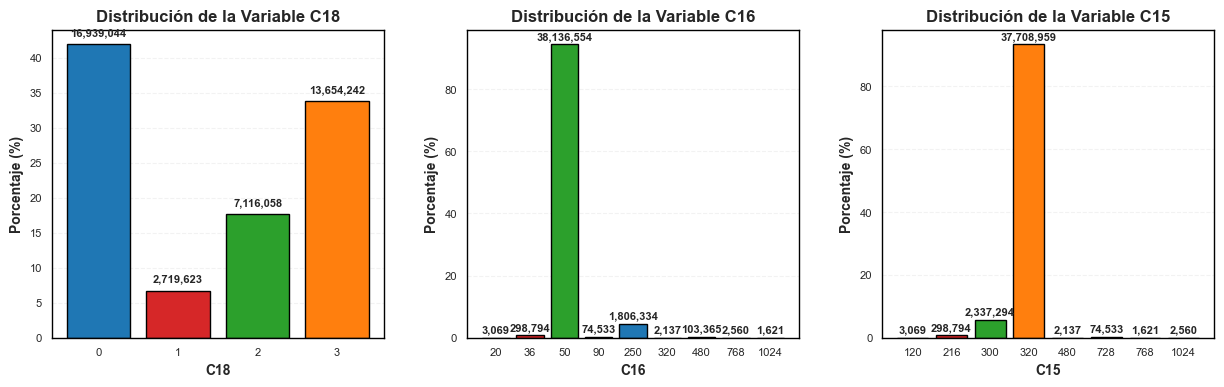

In [23]:
variables = ["C18", "C16", "C15"]
titles = [
    "Distribución de la Variable C18",
    "Distribución de la Variable C16",
    "Distribución de la Variable C15"
]

colors = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column, title in zip(axes, variables, titles):

    counts = df[column].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    bar_colors = [colors[i % len(colors)] for i in range(len(counts))]

    bars = ax.bar(
        counts.index.astype(str),
        percentages.values,
        color=bar_colors,
        edgecolor="black",
        linewidth=1
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(column, fontweight="bold")
    ax.set_ylabel("Porcentaje (%)", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", labelsize=8)

    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{count:,}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

plt.subplots_adjust(wspace=0.25)
plt.show()

Las distribuciones muestran que las tres variables presentan comportamientos bastante diferentes. En `C18` los registros se encuentran más repartidos entre sus cuatro categorías. La categoría 0 es la más frecuente, con 16,939,044 observaciones, seguida por la categoría 3 con 13,654,242. Las categorías 2 y 1 aparecen con menor frecuencia, pero siguen representando una parte visible del conjunto de datos.

En `C16` y `C15` la distribución está mucho más concentrada. Para `C16`, la categoría 50 reúne 38,136,554 registros, mientras que las demás aparecen con una frecuencia mucho menor. Algo similar ocurre con `C15`, donde la categoría 320 contiene 37,708,959 observaciones. Esto muestra que, aunque ambas variables cuentan con varias categorías posibles, la gran mayoría de los registros se concentra en un solo valor.

Estas diferencias son importantes para el análisis posterior. `C18` presenta una distribución más repartida y, además, fue la tercera variable con mayor asociación con `click` según Cramér's V. En el caso de `C15` y `C16`, su asociación con la respuesta también fue mayor que la de otras variables de baja cardinalidad, aunque sus distribuciones muestran que algunas categorías tienen una presencia muy reducida. Este comportamiento deberá tenerse en cuenta durante el preprocesamiento y el entrenamiento del modelo.

## Análisis de la Variable Temporal `hour`

La variable `hour` contiene información sobre el momento en el que se registró cada impresión publicitaria. Sin embargo, esta información se encuentra almacenada en un único valor con el formato `YYMMDDHH`, por lo que no resulta conveniente utilizarla directamente para el análisis.

A partir de esta variable se extraen características temporales que permitan estudiar por separado el día y la hora en la que ocurrió cada registro. También se construye una franja horaria para agrupar las horas del día en periodos más fáciles de interpretar.

In [16]:
df["datetime"] = pd.to_datetime(
    df["hour"].astype(str),
    format="%y%m%d%H"
)

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour_of_day"] = df["datetime"].dt.hour

df["time_band"] = pd.cut(
    df["hour_of_day"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Madrugada", "Mañana", "Tarde", "Noche"]
)

df[
    [
        "hour",
        "datetime",
        "year",
        "month",
        "day",
        "hour_of_day",
        "time_band"
    ]
].head(10)

,hour,datetime,year,month,day,hour_of_day,time_band
0,14102100,2014-10-21,2014,10,21,0,Madrugada
1,14102100,2014-10-21,2014,10,21,0,Madrugada
2,14102100,2014-10-21,2014,10,21,0,Madrugada
3,14102100,2014-10-21,2014,10,21,0,Madrugada
4,14102100,2014-10-21,2014,10,21,0,Madrugada
5,14102100,2014-10-21,2014,10,21,0,Madrugada
6,14102100,2014-10-21,2014,10,21,0,Madrugada
7,14102100,2014-10-21,2014,10,21,0,Madrugada
8,14102100,2014-10-21,2014,10,21,0,Madrugada
9,14102100,2014-10-21,2014,10,21,0,Madrugada


La transformación permite separar correctamente la información temporal contenida en `hour`. A partir de cada registro se obtiene la fecha correspondiente y sus componentes de año, mes, día y hora. También se incorpora una franja horaria que agrupa las 24 horas del día en madrugada, mañana, tarde y noche, facilitando el análisis de los patrones temporales presentes en los datos.

### Distribución Temporal de las Impresiones

Una vez separada la información contenida en `hour`, se analiza la distribución de las variables numéricas derivadas `day` y `hour_of_day`. La primera permite observar cómo se distribuyen los registros a lo largo de los días incluidos en el dataset, mientras que la segunda permite estudiar su comportamiento a través de las 24 horas del día.

Para representar estas distribuciones se utilizan histogramas, manteniendo intervalos acordes con los valores discretos que pueden tomar ambas variables.

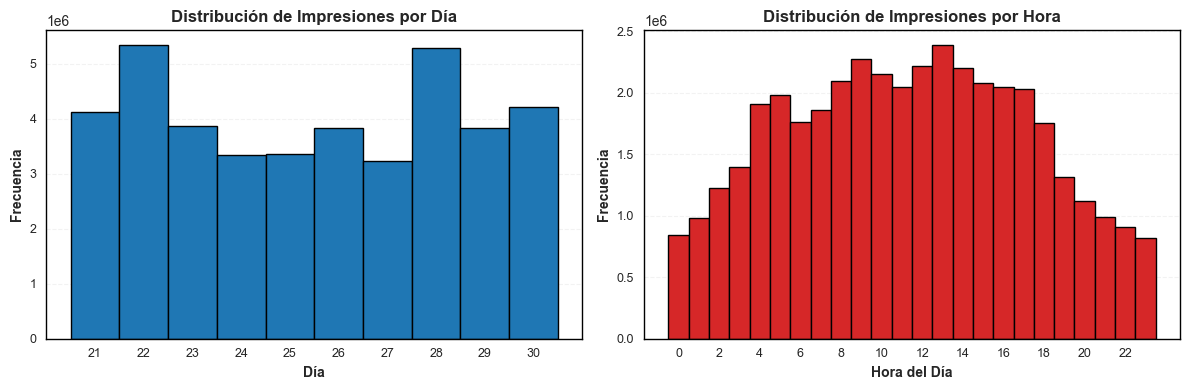

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#1f77b4", "#d62728"]

axes[0].hist(
    df["day"],
    bins=np.arange(df["day"].min() - 0.5, df["day"].max() + 1.5, 1),
    color=colors[0],
    edgecolor="black",
    linewidth=1
)

axes[0].set_title("Distribución de Impresiones por Día", fontweight="bold")
axes[0].set_xlabel("Día", fontweight="bold")
axes[0].set_ylabel("Frecuencia", fontweight="bold")
axes[0].set_xticks(sorted(df["day"].unique()))
axes[0].grid(axis="y", linestyle="--", alpha=0.25)
axes[0].set_axisbelow(True)

axes[1].hist(
    df["hour_of_day"],
    bins=np.arange(-0.5, 24.5, 1),
    color=colors[1],
    edgecolor="black",
    linewidth=1
)

axes[1].set_title("Distribución de Impresiones por Hora", fontweight="bold")
axes[1].set_xlabel("Hora del Día", fontweight="bold")
axes[1].set_ylabel("Frecuencia", fontweight="bold")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis="y", linestyle="--", alpha=0.25)
axes[1].set_axisbelow(True)

for ax in axes:
    ax.tick_params(axis="both", labelsize=9)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

Los histogramas muestran que la cantidad de impresiones varía a lo largo del periodo analizado. Los días 22 y 28 presentan las mayores frecuencias, con más de cinco millones de registros cada uno, mientras que el día 27 presenta la menor cantidad de impresiones.

La distribución por hora del día presenta una forma similar a una campana, con una menor cantidad de impresiones durante la madrugada, un aumento progresivo durante la mañana y las mayores frecuencias alrededor de las horas centrales del día. Posteriormente, la cantidad de registros comienza a disminuir hacia la noche. Aunque visualmente se observa este patrón, no se asume una distribución normal únicamente a partir de la forma del histograma.

<!-- ### Distribución de Clics por Hora del Día -->

Una vez analizada la distribución de las impresiones, se estudia cómo cambia la interacción con los anuncios a lo largo del día. Debido a que la cantidad de impresiones no es igual en todas las horas, utilizar únicamente el número de clics podría generar una comparación poco representativa.

Por esta razón, se calcula la tasa de clics (*Click-Through Rate*, CTR) para cada hora del día. Esta medida corresponde al porcentaje de impresiones que generaron un clic y permite comparar el nivel de interacción entre las distintas horas independientemente de la cantidad de anuncios mostrados.

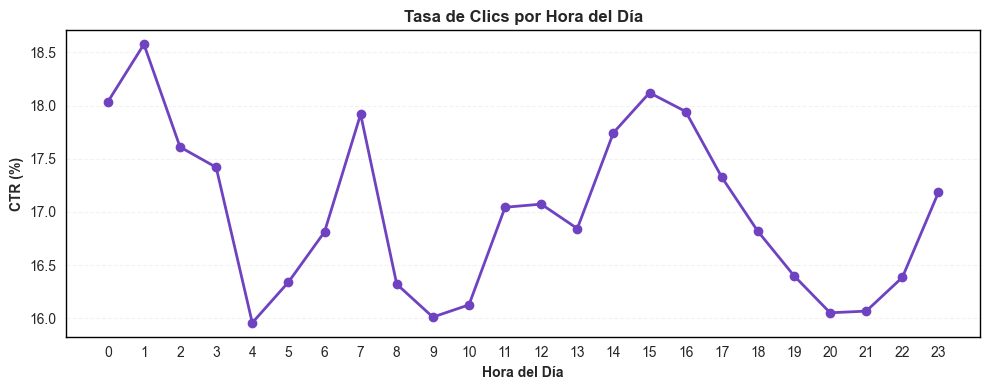

In [27]:
hourly_ctr = (
    df.groupby("hour_of_day", observed=True)["click"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 4))

plt.plot(
    hourly_ctr.index,
    hourly_ctr.values,
    marker="o",
    linewidth=2,
    markersize=6,
    color="#6f42c1"
)

plt.title(
    "Tasa de Clics por Hora del Día",
    fontweight="bold"
)

plt.xlabel(
    "Hora del Día",
    fontweight="bold"
)

plt.ylabel(
    "CTR (%)",
    fontweight="bold"
)

plt.xticks(range(24))

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax = plt.gca()
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()

El CTR cambia a lo largo del día, aunque en general se mantiene entre el 16% y el 18.6%. El valor más alto se presenta alrededor de la 1:00, mientras que los valores más bajos se observan cerca de las 4:00, 9:00 y entre las 20:00 y 21:00. También se puede notar un aumento entre las 14:00 y 16:00.

Al comparar estos resultados con el histograma anterior, se observa que tener **una mayor cantidad de impresiones no implica necesariamente obtener una mayor proporción de clics**. Por ejemplo, alrededor de las 13:00 se registra una gran cantidad de impresiones, pero el CTR no se encuentra entre los valores más altos del día.

### Correlación de las Variables Temporales

Finalmente, se analiza la correlación entre las variables numéricas creadas a partir de `hour` y la variable objetivo `click`. Para este análisis se utilizan `day` y `hour_of_day`, mientras que `year` y `month` no se incluyen debido a que presentan poca o ninguna variación dentro del periodo registrado.

La matriz permite observar si existe alguna relación lineal entre estas características temporales y la ocurrencia de un clic.

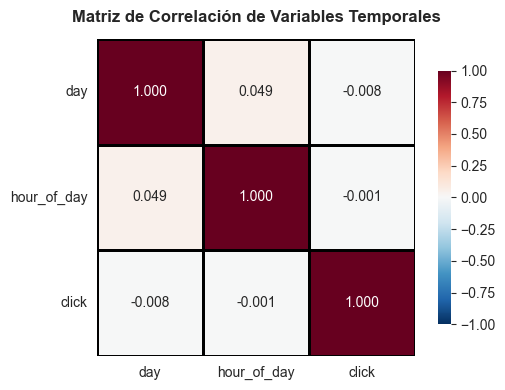

In [28]:
correlation_variables = [
    "day",
    "hour_of_day",
    "click"
]

correlation_matrix = df[correlation_variables].corr()

plt.figure(figsize=(5.5, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="black",
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Matriz de Correlación de Variables Temporales",
    fontweight="bold",
    pad=12
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

La matriz muestra que la correlación de `day` y `hour_of_day` con `click` es prácticamente nula, con valores de -0.008 y -0.001, respectivamente. Esto significa que no existe una relación lineal clara en la que el aumento del día o de la hora esté acompañado por un aumento o una disminución constante en la probabilidad de recibir un clic.

En el caso de `hour_of_day`, este resultado no significa que la hora sea irrelevante. En la gráfica anterior se observó que el CTR cambia durante el día, pero lo hace mediante aumentos y disminuciones en diferentes horas, y no siguiendo una tendencia constante. Por esta razón, una correlación lineal puede ser cercana a cero incluso cuando existen diferencias en el comportamiento de los clics según la hora.

La relación entre `day` y `hour_of_day` también es muy baja, con una correlación de 0.049, por lo que ambas variables aportan información temporal diferente y no presentan una relación lineal importante entre ellas.